In [ ]:
import pandas as pd

df = pd.read_csv("eo1_nyc (1).csv")

df.head()
# Check shape and column names
print("Rows and columns:", df.shape)
print("\nColumn names:", df.columns.tolist())

Rows and columns: (48066, 28)

Column names: ['EIN', 'NAME', 'ICO', 'STREET', 'CITY', 'STATE', 'ZIP', 'GROUP', 'SUBSECTION', 'AFFILIATION', 'CLASSIFICATION', 'RULING', 'DEDUCTIBILITY', 'FOUNDATION', 'ACTIVITY', 'ORGANIZATION', 'STATUS', 'TAX_PERIOD', 'ASSET_CD', 'INCOME_CD', 'FILING_REQ_CD', 'PF_FILING_REQ_CD', 'ACCT_PD', 'ASSET_AMT', 'INCOME_AMT', 'REVENUE_AMT', 'NTEE_CD', 'SORT_NAME']


Columns we're working with: ['EIN', 'NAME', 'STREET', 'CITY', 'STATE', 'ZIP', 'SUBSECTION', 'NTEE_CD', 'ASSET_AMT', 'INCOME_AMT', 'REVENUE_AMT']
Rows and columns: (48066, 11)
BOROUGH
Manhattan        20872
Brooklyn         15697
Bronx             4042
Queens            3256
Unknown           2484
Staten Island     1715
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


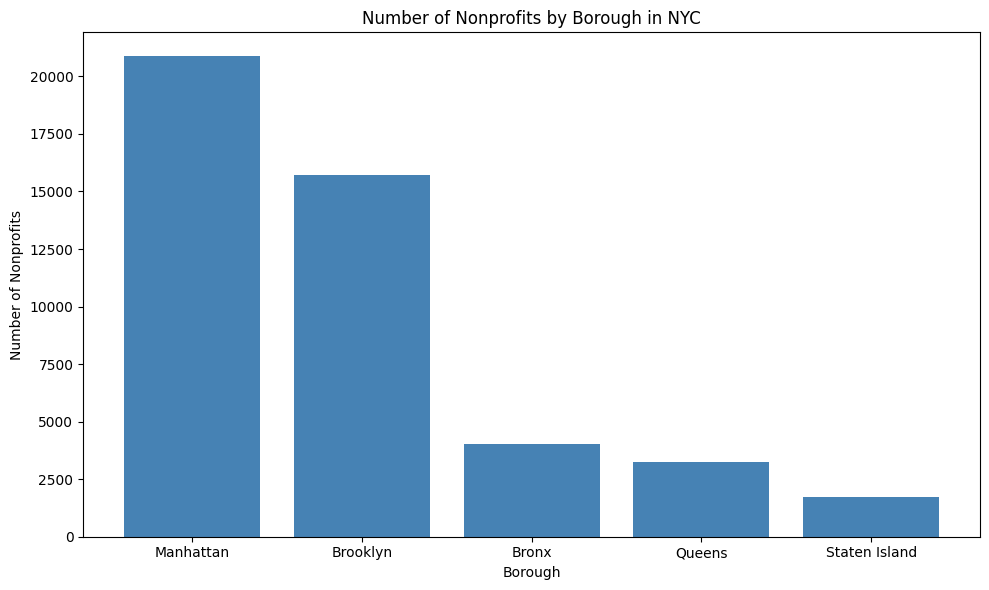

In [7]:
# Let's check for missing values in each column
# A missing value means a cell is empty - pandas calls these "NaN"
df.isnull().sum()
# We don't need all 28 columns for our analysis
# Let's keep only the ones that are useful to us
df = df[['EIN', 'NAME', 'STREET', 'CITY', 'STATE', 'ZIP', 
         'SUBSECTION', 'NTEE_CD', 'ASSET_AMT', 'INCOME_AMT', 'REVENUE_AMT']]

# Confirm what we kept
print("Columns we're working with:", df.columns.tolist())
print("Rows and columns:", df.shape)
# NYC zip codes start with different numbers depending on the borough
# We can use that to figure out which borough each nonprofit is in

def get_borough(zip_code):
    zip_str = str(zip_code)[:5]  # grab just the first 5 digits
    if zip_str.startswith("100") or zip_str.startswith("101") or zip_str.startswith("102"):
        return "Manhattan"
    elif zip_str.startswith("104"):
        return "Bronx"
    elif zip_str.startswith("112"):
        return "Brooklyn"
    elif zip_str.startswith("113") or zip_str.startswith("116"):
        return "Queens"
    elif zip_str.startswith("103"):
        return "Staten Island"
    else:
        return "Unknown"

df["BOROUGH"] = df["ZIP"].apply(get_borough)

print(df["BOROUGH"].value_counts())
import matplotlib.pyplot as plt

# Count nonprofits per borough (excluding Unknown)
borough_counts = df[df["BOROUGH"] != "Unknown"]["BOROUGH"].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(borough_counts.index, borough_counts.values, color="steelblue")
plt.title("Number of Nonprofits by Borough in NYC")
plt.xlabel("Borough")
plt.ylabel("Number of Nonprofits")
plt.tight_layout()
plt.show()

## Data Cleaning

Before we analyze anything, we need to understand what's in our data
and fix any problems we find. This is called "data cleaning."

## Visualization 1: Nonprofits by Borough

**What this chart shows:** Manhattan has by far the most nonprofits (20,872), 
followed by Brooklyn (15,697). The Bronx, Queens, and Staten Island have 
significantly fewer — which is interesting given their population sizes.

**Why a bar chart:** Bar charts are great for comparing counts across categories 
like boroughs.

**Design choice:** Used a single color (steel blue) to keep it clean and simple.

# NYC Nonprofit Analysis
## Code:You Data Analysis Keystone Project

**Dataset:** IRS Exempt Organizations Business Master File — filtered to New York City  
**Goal:** Explore the distribution, types, and focus areas of NYC nonprofits, with a 
particular focus on faith-based organizations and child welfare nonprofits.

**Analysis Questions:**
1. Which boroughs have the most nonprofits?
2. How are faith-based organizations spread across boroughs?
3. How many nonprofits focus on child welfare, adoption, or foster care?
4. Are adoption/foster care nonprofits concentrated in certain areas?
5. Does nonprofit presence match community need?

In [8]:
# SUBSECTION 3 means the organization is a 501(c)(3)
# Religious organizations typically have NTEE_CD starting with "X"
# NTEE codes are a classification system for nonprofits

faith_df = df[df["NTEE_CD"].str.startswith("X", na=False)]

print("Total faith-based organizations:", len(faith_df))
print(faith_df["BOROUGH"].value_counts())

Total faith-based organizations: 8407
BOROUGH
Brooklyn         4699
Bronx            1028
Manhattan         992
Queens            869
Unknown           580
Staten Island     239
Name: count, dtype: int64


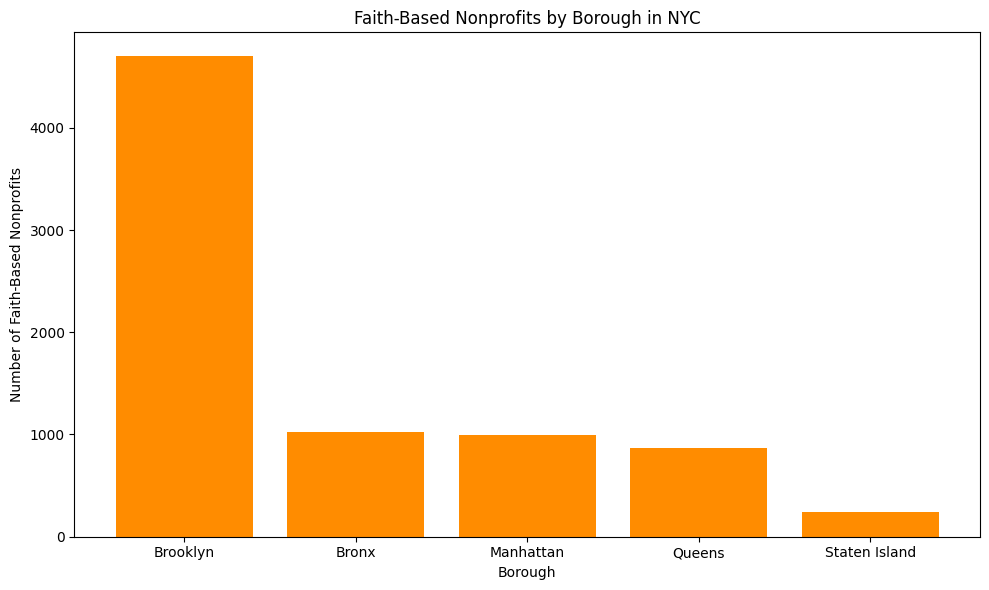

In [9]:
# Make a bar chart for faith-based organizations by borough
faith_by_borough = faith_df[faith_df["BOROUGH"] != "Unknown"]["BOROUGH"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(faith_by_borough.index, faith_by_borough.values, color="darkorange")
plt.title("Faith-Based Nonprofits by Borough in NYC")
plt.xlabel("Borough")
plt.ylabel("Number of Faith-Based Nonprofits")
plt.tight_layout()
plt.show()

In [10]:
# NTEE codes starting with "P" cover Human Services
# "P30" specifically covers children and youth services
# We'll also search names for adoption/foster care keywords

child_welfare_df = df[
    df["NTEE_CD"].str.startswith("P3", na=False) |
    df["NAME"].str.contains("CHILD|ADOPTION|FOSTER|YOUTH", case=False, na=False)
]

print("Total child welfare/adoption nonprofits:", len(child_welfare_df))
print(child_welfare_df["BOROUGH"].value_counts())

Total child welfare/adoption nonprofits: 1112
BOROUGH
Manhattan        427
Brooklyn         365
Bronx            133
Unknown           70
Queens            68
Staten Island     49
Name: count, dtype: int64


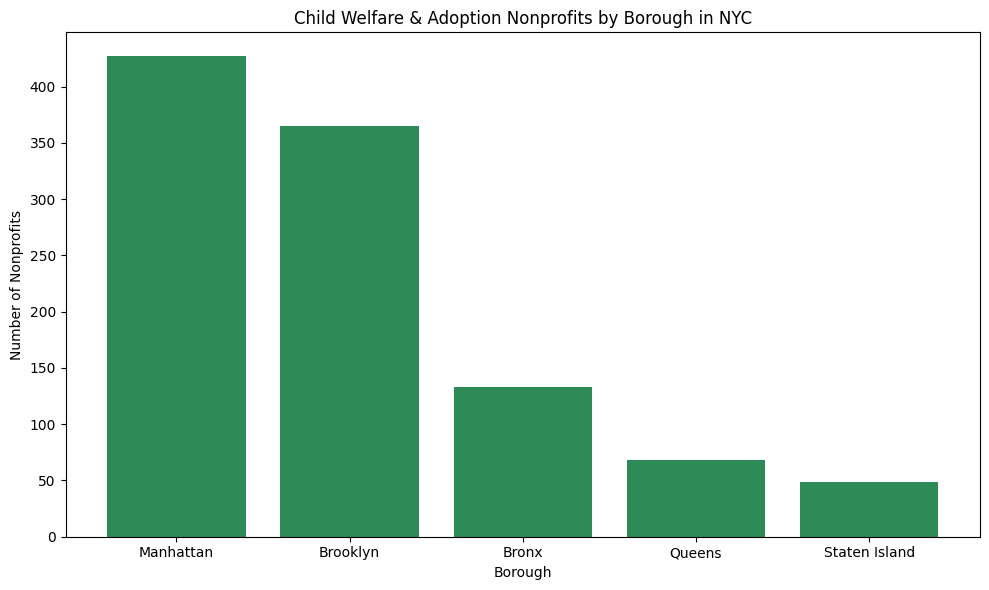

In [11]:
# Make a bar chart for child welfare nonprofits by borough
child_by_borough = child_welfare_df[child_welfare_df["BOROUGH"] != "Unknown"]["BOROUGH"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(child_by_borough.index, child_by_borough.values, color="seagreen")
plt.title("Child Welfare & Adoption Nonprofits by Borough in NYC")
plt.xlabel("Borough")
plt.ylabel("Number of Nonprofits")
plt.tight_layout()
plt.show()

## Visualization 2: Faith-Based Nonprofits by Borough

I was curious whether faith-based orgs would follow the same pattern as overall 
nonprofits. Turns out Brooklyn actually has the most (4,699) even though Manhattan 
had more nonprofits overall. That surprised me!

I used a bar chart again because it's the easiest way to compare numbers across 
boroughs. I picked orange so it's easy to tell apart from the first chart.

## Visualization 3: Child Welfare & Adoption Nonprofits by Borough

I searched for nonprofits focused on children, adoption, and foster care, which is something I care about personally. I found 1,112 of them across NYC.

Manhattan and Brooklyn lead, but the Bronx stood out to me. It has more child welfare orgs than I expected given its smaller overall nonprofit count.

I used green to make this chart visually distinct from the others.

## Summary & Findings

Here's what I found after exploring the dataset:

1. Manhattan has the most nonprofits overall (20,872), way more than any other borough
2. Brooklyn surprised me by leading in faith-based organizations (4,699) even though Manhattan has more nonprofits total
3. I found 1,112 nonprofits focused on child welfare, adoption, or foster care across NYC
4. The Bronx had more child welfare orgs than I expected given its smaller size
5. I'd love to come back to this dataset and merge it with census poverty data to see if nonprofit presence actually lines up with where need is highest. That would make for a really interesting capstone project

In [12]:
df.describe()

,EIN,SUBSECTION,ASSET_AMT,INCOME_AMT,REVENUE_AMT
count,4.806600e+04,48066.000000,3.430900e+04,3.430900e+04,2.805900e+04
mean,4.319135e+08,3.468065,1.928963e+07,1.196136e+07,9.217916e+06
std,3.178564e+08,4.425660,3.354023e+08,2.546049e+08,1.818967e+08
min,2.022084e+06,1.000000,0.000000e+00,-1.770640e+07,-5.091937e+06
25%,1.336768e+08,3.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.311546e+08,3.000000,3.583200e+04,4.832500e+04,1.704000e+04
75%,8.220217e+08,3.000000,1.020351e+06,6.606560e+05,4.847720e+05
max,9.966271e+08,92.000000,2.480109e+10,2.735145e+10,1.217259e+10


## Exploratory Data Analysis (EDA)

I ran df.describe() to get a feel for the numeric columns. A few things I noticed:

- There are 48,066 organizations total
- ASSET_AMT and INCOME_AMT have a huge range — the max is in the billions, 
  but the median (50%) is much lower, meaning most nonprofits are small
- Some INCOME_AMT values are negative which is a little surprising
- SUBSECTION ranges from 1 to 92, which tells me there are many different 
  types of tax-exempt organizations in this dataset

In [13]:
# Let's check what data type each column is
# This helps us know if anything needs to be converted before we analyze it
print(df.dtypes)

EIN              int64
NAME               str
STREET             str
CITY               str
STATE              str
ZIP                str
SUBSECTION       int64
NTEE_CD            str
ASSET_AMT      float64
INCOME_AMT     float64
REVENUE_AMT    float64
BOROUGH            str
dtype: object


The data types all look correct. Text columns like NAME and CITY are strings, 
and the money columns like ASSET_AMT are floats (decimal numbers). 
I don't need to convert anything, so I can move on to analysis.